In [2]:
# Imports
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve,
    precision_recall_curve
)
import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load data from SQL
conn = sqlite3.connect('../data/credit_default.db')

# Read training data view
df = pd.read_sql_query("SELECT * FROM training_data;", conn)
conn.close()

print(f"Dataset shape: {df.shape}")
print(f"\nDefault rate: {df['default_label'].mean():.2%}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (30000, 17)

Default rate: 22.12%

First few rows:


,customer_id,age,sex,education,marriage,num_accounts,total_credit_limit,avg_repay_status,max_delay_ever,total_late_payments,total_serious_delays,avg_bill,avg_payment,avg_pay_ratio,avg_utilization,max_utilization,default_label
0,1,24,2,2,1,1,20000,-0.333333,2,2,2,1284.000000,114.833333,0.5,0.0,0,1
1,2,26,2,2,2,1,120000,0.500000,2,2,2,2846.166667,833.333333,0.0,0.0,0,1
2,3,34,2,2,2,1,90000,0.000000,0,0,0,16942.166667,1836.333333,0.0,0.0,0,0
3,4,37,2,2,1,1,50000,0.000000,0,0,0,38555.666667,1398.000000,0.0,0.0,0,0
4,5,57,1,2,1,1,50000,-0.333333,0,0,0,18223.166667,9841.500000,1.0,0.0,0,0


In [5]:
# Prepare features and target
# Drop customer_id and extract target
y = df['default_label']
X = df.drop(columns=['customer_id', 'default_label'])

print(f"Features: {X.shape[1]}")
print(f"Class distribution:\n{y.value_counts()}")

Features: 15
Class distribution:
default_label
0    23364
1     6636
Name: count, dtype: int64


In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Train set: 24000 samples
Test set: 6000 samples


In [7]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Model 1 - Logistic Regression
print("=" * 60)
print("MODEL 1: Logistic Regression")
print("=" * 60)

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

MODEL 1: Logistic Regression

AUC-ROC: 0.7494

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.82      4673
           1       0.44      0.61      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.74      0.75      6000



In [9]:
# Model 2 - Random Forest
print("=" * 60)
print("MODEL 2: Random Forest")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

MODEL 2: Random Forest

AUC-ROC: 0.7663

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.83      4673
           1       0.46      0.61      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.79      0.76      0.77      6000



In [10]:
# Model 3 - XGBoost
print("=" * 60)
print("MODEL 3: XGBoost")
print("=" * 60)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum()  # Handle imbalance
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

MODEL 3: XGBoost

AUC-ROC: 0.7665

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      4673
           1       0.44      0.64      0.52      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.71      0.67      6000
weighted avg       0.79      0.74      0.76      6000



In [11]:
# Model 4 - LightGBM
print("=" * 60)
print("MODEL 4: LightGBM")
print("=" * 60)

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced'
)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))


MODEL 4: LightGBM
[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 892
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [12]:
# Compare all models
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_xgb),
        roc_auc_score(y_test, y_pred_proba_lgb)
    ]
})
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(models_comparison.to_string(index=False))


MODEL COMPARISON
              Model  AUC-ROC
Logistic Regression 0.749406
      Random Forest 0.766343
            XGBoost 0.766512
           LightGBM 0.766449


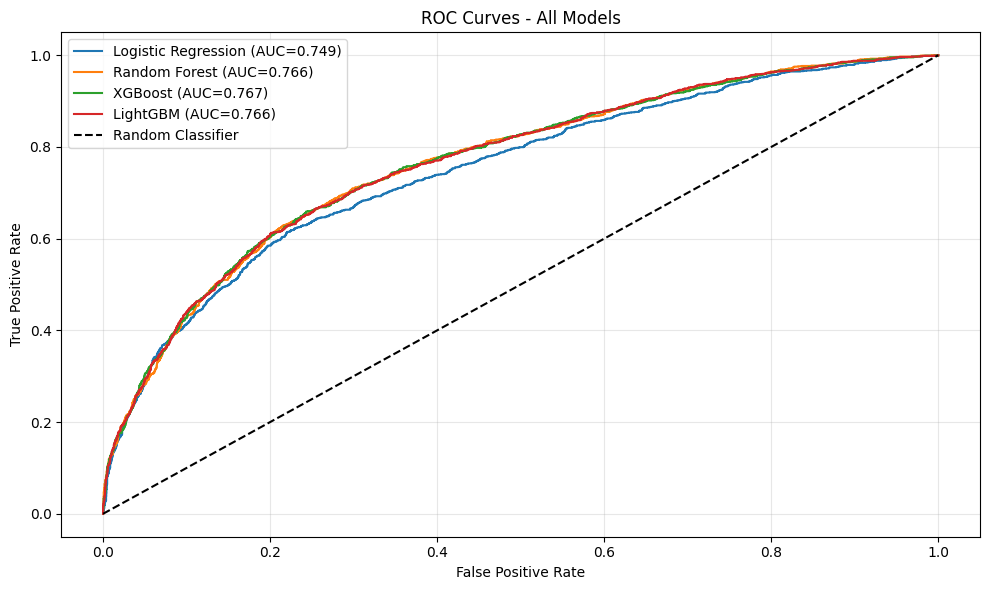

In [13]:
# ROC Curves comparison
plt.figure(figsize=(10, 6))

for name, y_proba in [
    ('Logistic Regression', y_pred_proba_lr),
    ('Random Forest', y_pred_proba_rf),
    ('XGBoost', y_pred_proba_xgb),
    ('LightGBM', y_pred_proba_lgb)
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

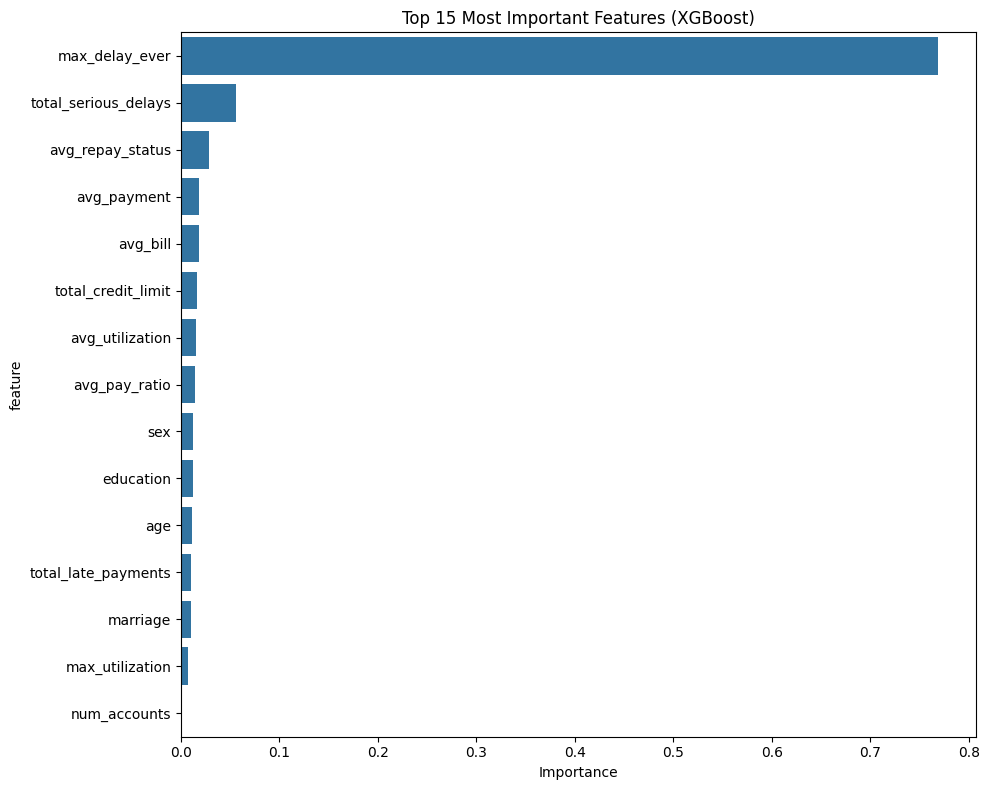


Top 10 Features:
             feature  importance
      max_delay_ever    0.769056
total_serious_delays    0.056307
    avg_repay_status    0.028051
         avg_payment    0.018573
            avg_bill    0.018159
  total_credit_limit    0.016776
     avg_utilization    0.015334
       avg_pay_ratio    0.014782
                 sex    0.012191
           education    0.012136


In [14]:
# Feature importance (XGBoost)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))


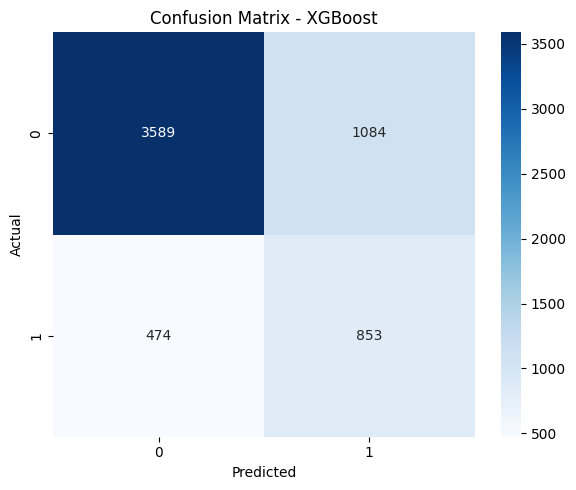

In [15]:
# Confusion Matrix (Best Model - XGBoost)
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.show()

In [16]:
# Save results
results = pd.DataFrame({
    'customer_id': df.loc[X_test.index, 'customer_id'].values,
    'actual_default': y_test.values,
    'predicted_default': y_pred_xgb,
    'default_probability': y_pred_proba_xgb
})

results.to_csv('../data/predictions.csv', index=False)
print("✅ Predictions saved to data/predictions.csv")

✅ Predictions saved to data/predictions.csv
